In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from termcolor import colored

# Load the dataset
file_path = 'datasetFolder/processed_dataset2.csv'  # Replace with the path to your dataset
data = pd.read_csv(file_path, encoding='latin-1')

# Rename columns for clarity (if not already clear)
data.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Split into features and target
X = data['text']  # The stemmed text
y = data['target']  # Target labels (0 = negative, 1 = positive)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text using TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Unigrams + Bigrams
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# Make predictions
y_pred = nb_model.predict(X_test_vec)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(colored(f"Naive Bayes Accuracy: {accuracy:.4f}", 'green'))



Naive Bayes Accuracy: 0.7773


In [11]:
# You can add error metrics if necessary, like Mean Absolute Error or Mean Squared Error
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

accuracy = accuracy_score(y_test, y_pred)
print(colored(f"Naive Bayes Accuracy: {accuracy:.4f}", 'green'))

print(colored(f"\nMean Absolute Error (MAE): {mae:.4f}", 'red'))
print(colored(f"Mean Squared Error (MSE): {mse:.4f}", 'magenta'))
print(colored(f"Root Mean Squared Error (RMSE): {rmse:.4f}", 'magenta'))

# Classification Report with colors
report = classification_report(y_test, y_pred)
print(colored("\nClassification Report:", 'blue'))
print(colored(report, 'white'))

Naive Bayes Accuracy: 0.7773

Mean Absolute Error (MAE): 0.2227
Mean Squared Error (MSE): 0.2227
Root Mean Squared Error (RMSE): 0.4719

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78    159444
           1       0.79      0.75      0.77    160455

    accuracy                           0.78    319899
   macro avg       0.78      0.78      0.78    319899
weighted avg       0.78      0.78      0.78    319899



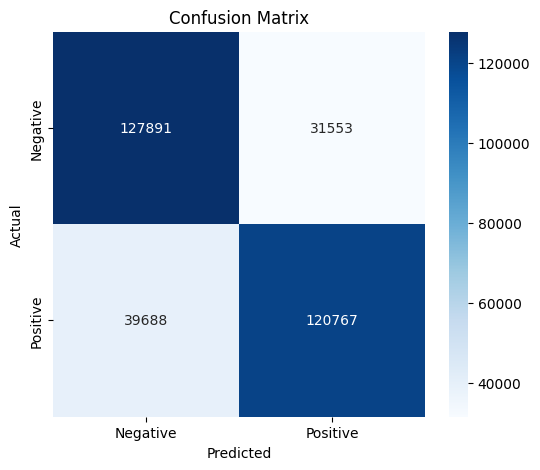

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
